<a href="https://colab.research.google.com/github/toche7/MLPython1Day/blob/main/HealthScreeningSurvey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dataset 3 — Health Screening Survey

ผลตรวจสุขภาพประจำปี 300 ราย

| Column | ประเภท |
|---|---|
| BMI  | Feature |
| น้ำตาล | Feature |
|  ความดัน | Feature |
| การออกกำลังกาย | Feature |
| ประวัติครอบครัว | Feature |
| กลุ่มเสี่ยงโรค (สูง/กลาง/ต่ำ) | **Target** |

In [ ]:
# Install Thai fonts
!apt-get install -y fonts-thai-tlwg


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Specifically look for Thai fonts in the system path
thai_font_paths = [
    '/usr/share/fonts/truetype/thai/Laksaman.ttf',
    '/usr/share/fonts/truetype/tlwg/Laksaman.ttf',
    '/usr/share/fonts/truetype/thai/Garuda.ttf'
]

target_font = None
for path in thai_font_paths:
    if os.path.exists(path):
        target_font = path
        break

if target_font:
    fe = fm.FontEntry(fname=target_font, name='ThaiFont')
    fm.fontManager.ttflist.insert(0, fe)
    plt.rcParams['font.family'] = 'ThaiFont'
    print(f'Successfully set font to: {target_font}')
else:
    print('Could not find specific Thai font files. Please ensure fonts-thai-tlwg is installed.')

plt.rcParams['axes.unicode_minus'] = False

Successfully set font to: /usr/share/fonts/truetype/tlwg/Laksaman.ttf


In [ ]:
import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

num_samples = 300

# Generate synthetic data for features
bmi = np.random.normal(loc=25, scale=5, size=num_samples) # BMI, normal distribution around 25
sugar = np.random.normal(loc=100, scale=15, size=num_samples) # Blood sugar, normal distribution around 100
blood_pressure = np.random.normal(loc=120, scale=10, size=num_samples) # Blood pressure, normal distribution around 120
exercise_levels = np.random.choice(['น้อย', 'ปานกลาง', 'มาก'], size=num_samples, p=[0.2, 0.5, 0.3])
family_history = np.random.choice(['ไม่มี', 'มี'], size=num_samples, p=[0.7, 0.3])

# Generate target variable 'กลุ่มเสี่ยงโรค' (Disease Risk Group)
# This is a simplified rule-based generation to ensure some correlation for ML task
risk_groups = []
for i in range(num_samples):
    risk_score = 0
    if bmi[i] > 30: risk_score += 2
    elif bmi[i] > 25: risk_score += 1

    if sugar[i] > 120: risk_score += 2
    elif sugar[i] > 100: risk_score += 1

    if blood_pressure[i] > 140: risk_score += 2
    elif blood_pressure[i] > 130: risk_score += 1

    if exercise_levels[i] == 'น้อย': risk_score += 1
    if family_history[i] == 'มี': risk_score += 1

    # Modified: Lower threshold for 'สูง' to increase its count
    if risk_score >= 4:
        risk_groups.append('สูง')
    elif risk_score >= 2:
        risk_groups.append('กลาง')
    else:
        risk_groups.append('ต่ำ')

# Create DataFrame
health_survey_df = pd.DataFrame({
    'BMI': bmi,
    'น้ำตาล': sugar,
    'ความดัน': blood_pressure,
    'การออกกำลังกาย': exercise_levels,
    'ประวัติครอบครัว': family_history,
    'กลุ่มเสี่ยงโรค': risk_groups
})

# Display the first 5 rows of the dataset
print("First 5 rows of the Health Screening Survey dataset:")
display(health_survey_df.head())

# Display dataset information
print("\nDataset Information:")
health_survey_df.info()

# Display updated class counts for 'กลุ่มเสี่ยงโรค'
print("\nUpdated Class Counts for 'กลุ่มเสี่ยงโรค':")
display(health_survey_df['กลุ่มเสี่ยงโรค'].value_counts())

First 5 rows of the Health Screening Survey dataset:


,BMI,น้ำตาล,ความดัน,การออกกำลังกาย,ประวัติครอบครัว,กลุ่มเสี่ยงโรค
0,27.483571,87.565075,127.569886,น้อย,มี,กลาง
1,24.308678,91.597284,110.778347,มาก,ไม่มี,ต่ำ
2,28.238443,111.209404,128.696059,มาก,มี,กลาง
3,32.615149,109.155554,133.556379,ปานกลาง,ไม่มี,สูง
4,23.829233,99.686476,124.134349,น้อย,มี,กลาง



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   BMI              300 non-null    float64
 1   น้ำตาล           300 non-null    float64
 2   ความดัน          300 non-null    float64
 3   การออกกำลังกาย   300 non-null    object 
 4   ประวัติครอบครัว  300 non-null    object 
 5   กลุ่มเสี่ยงโรค   300 non-null    object 
dtypes: float64(3), object(3)
memory usage: 14.2+ KB

Updated Class Counts for 'กลุ่มเสี่ยงโรค':


,count
กลุ่มเสี่ยงโรค,
กลาง,154
ต่ำ,115
สูง,31


<Figure size 1000x800 with 0 Axes>

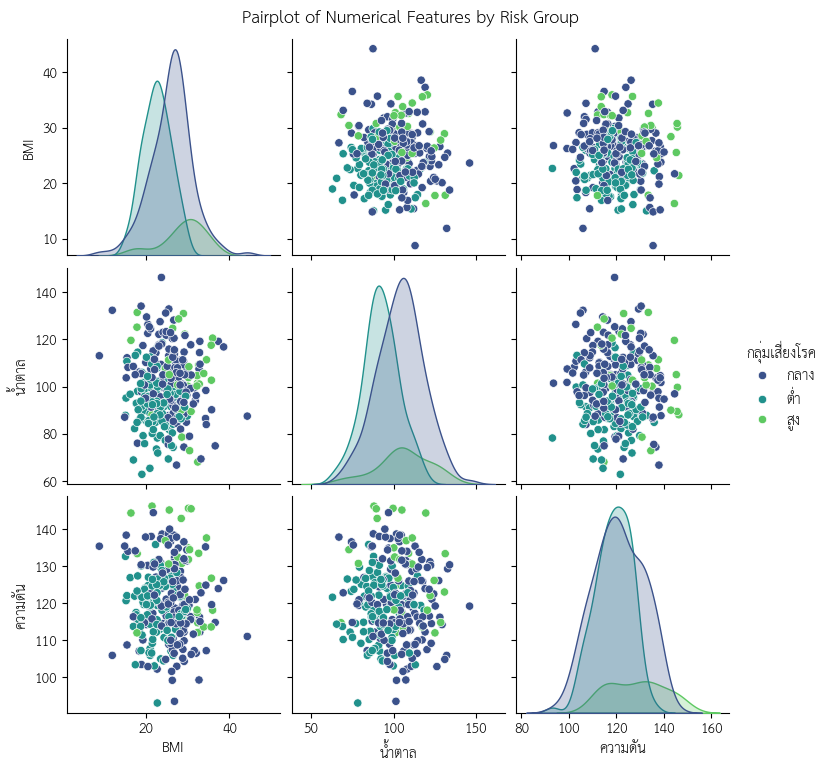

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the numerical features to be included in the pairplot
numerical_features = ['BMI', 'น้ำตาล', 'ความดัน']

# Create a pairplot, highlighting the 'กลุ่มเสี่ยงโรค' (risk group)
# This will show the distributions and relationships between numerical features
# for each risk group, making it easier to see how 'สูง' differs.
plt.figure(figsize=(10, 8))
sns.pairplot(health_survey_df, vars=numerical_features, hue='กลุ่มเสี่ยงโรค', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features by Risk Group', y=1.02) # Add a title to the plot
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define features (X) and target (y)
X = health_survey_df.drop('กลุ่มเสี่ยงโรค', axis=1)
y = health_survey_df['กลุ่มเสี่ยงโรค']

# Identify numerical and categorical features
numerical_features = ['BMI', 'น้ำตาล', 'ความดัน']
categorical_features = ['การออกกำลังกาย', 'ประวัติครอบครัว']

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create a machine learning pipeline
# Added class_weight='balanced' to help with class imbalance
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training the RandomForestClassifier with balanced class weights...")
model_pipeline.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
# Added zero_division=0 to silence warnings if a class is still not predicted
report = classification_report(y_test, y_pred, zero_division=0)

print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

print("\nML task completed with class weighting.")

Training the RandomForestClassifier with balanced class weights...
Training complete.

Model Accuracy: 0.8167

Classification Report:
              precision    recall  f1-score   support

        กลาง       0.78      0.90      0.84        31
         ต่ำ       0.88      0.91      0.89        23
         สูง       0.00      0.00      0.00         6

    accuracy                           0.82        60
   macro avg       0.55      0.61      0.58        60
weighted avg       0.74      0.82      0.77        60


ML task completed with class weighting.


### Feature Engineering
We will create new features to help the model:
1. **Interaction Features**: Multiply numerical features to capture combined effects.
2. **Risk Flags**: Create boolean indicators for high BMI, high sugar, and high blood pressure.

In [ ]:
# 1. Create Risk Flags (Boolean) based on common medical thresholds
health_survey_df['high_bmi_flag'] = (health_survey_df['BMI'] > 30).astype(int)
health_survey_df['high_sugar_flag'] = (health_survey_df['น้ำตาล'] > 120).astype(int)
health_survey_df['high_bp_flag'] = (health_survey_df['ความดัน'] > 140).astype(int)

# 2. Create Interaction terms
health_survey_df['bmi_sugar_inter'] = health_survey_df['BMI'] * health_survey_df['น้ำตาล']

# Update feature lists for the model
X_engineered = health_survey_df.drop('กลุ่มเสี่ยงโรค', axis=1)
y_engineered = health_survey_df['กลุ่มเสี่ยงโรค']

# Re-identify features
num_feat_eng = ['BMI', 'น้ำตาล', 'ความดัน', 'bmi_sugar_inter']
cat_feat_eng = ['การออกกำลังกาย', 'ประวัติครอบครัว', 'high_bmi_flag', 'high_sugar_flag', 'high_bp_flag']

print("New features created. Ready to retrain.")
display(X_engineered.head())

New features created. Ready to retrain.


,BMI,น้ำตาล,ความดัน,การออกกำลังกาย,ประวัติครอบครัว,high_bmi_flag,high_sugar_flag,high_bp_flag,bmi_sugar_inter
0,27.483571,87.565075,127.569886,น้อย,มี,0,0,0,2406.600931
1,24.308678,91.597284,110.778347,มาก,ไม่มี,0,0,0,2226.608937
2,28.238443,111.209404,128.696059,มาก,มี,0,0,0,3140.380384
3,32.615149,109.155554,133.556379,ปานกลาง,ไม่มี,1,0,0,3560.124688
4,23.829233,99.686476,124.134349,น้อย,มี,0,0,0,2375.452278


In [ ]:
# Retrain with engineered features
preprocessor_eng = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_feat_eng),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feat_eng)
    ])

model_pipeline_eng = Pipeline(steps=[
    ('preprocessor', preprocessor_eng),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))
])

# Split and fit
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_engineered, y_engineered, test_size=0.2, random_state=42, stratify=y_engineered)

model_pipeline_eng.fit(X_train_e, y_train_e)
y_pred_e = model_pipeline_eng.predict(X_test_e)

print("Updated Classification Report with Feature Engineering:")
print(classification_report(y_test_e, y_pred_e, zero_division=0))

Updated Classification Report with Feature Engineering:
              precision    recall  f1-score   support

        กลาง       0.83      0.94      0.88        31
         ต่ำ       0.91      0.91      0.91        23
         สูง       1.00      0.33      0.50         6

    accuracy                           0.87        60
   macro avg       0.91      0.73      0.76        60
weighted avg       0.88      0.87      0.85        60



In [ ]:
print(f"Overall Model Accuracy: {accuracy_score(y_test_e, y_pred_e):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test_e, y_pred_e, zero_division=0))

Overall Model Accuracy: 86.67%

Detailed Classification Report:
              precision    recall  f1-score   support

        กลาง       0.83      0.94      0.88        31
         ต่ำ       0.91      0.91      0.91        23
         สูง       1.00      0.33      0.50         6

    accuracy                           0.87        60
   macro avg       0.91      0.73      0.76        60
weighted avg       0.88      0.87      0.85        60



In [ ]:
# Save the dataset to CSV
health_survey_df.to_csv('healthSurveyData.csv', index=False)
print('File saved as healthSurveyData.csv')


File saved as healthSurveyData.csv
